**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, mean_squared_error,recall_score,confusion_matrix
from sklearn.linear_model import Lasso
import seaborn as sns

**Load Dataset**

In [2]:
df = pd.read_csv("employee_turnover.csv")

In [3]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [4]:
df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [6]:
df.nunique()

Job_Satisfaction                           900
Performance_Rating                         900
Years_At_Company                           900
Work_Life_Balance                          900
Distance_From_Home                         900
Monthly_Income                             900
Education_Level                            900
Age                                        900
Num_Companies_Worked                       900
Employee_Role                              900
Annual_Bonus                               900
Training_Hours                             900
Department                                 900
Annual_Bonus_Squared                       900
Annual_Bonus_Training_Hours_Interaction    900
Employee_Turnover                            2
dtype: int64

In [7]:
x = df.drop("Employee_Turnover",axis = 1)
x.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000


In [8]:
y = df["Employee_Turnover"]
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Employee_Turnover, dtype: int64

<Axes: >

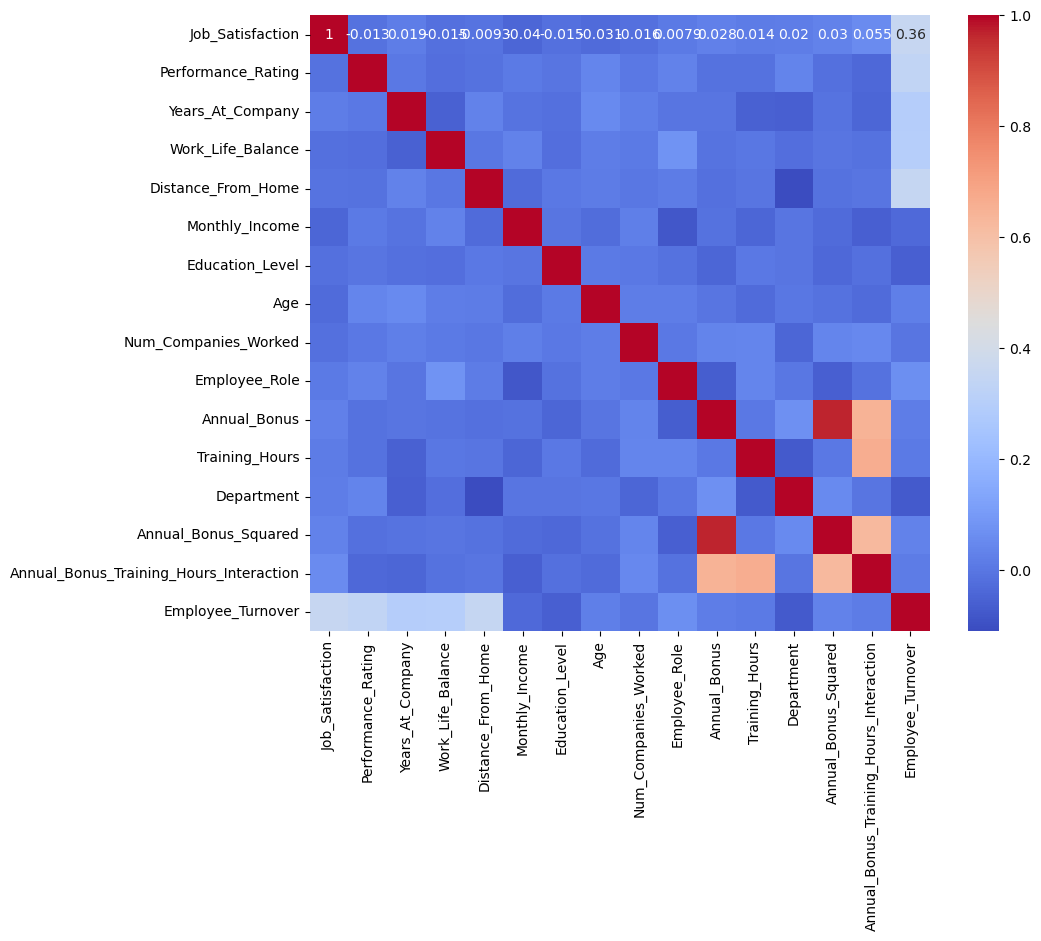

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

**Train Test Split**

In [10]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

**Fit Model Logistic Regression**

In [11]:
#model 
model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(x_test)

In [13]:
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0], dtype=int64)

**Accuracy**

In [14]:
print("accuracy",accuracy_score(y_test, y_pred)*100,"%")
print("precision",precision_score(y_test,y_pred)*100, "%")

accuracy 85.92592592592592 %
precision 87.17948717948718 %


In [17]:
alphas = [0.01,1,20,3,30,40,50,0.02,60,70,80,90,0.3]
mses = []
for a in alphas:
    lasso_model = Lasso(alpha = a)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mses)
print("accuracy",accuracy_score(y_test, y_pred)*100,"%")
print("precision",precision_score(y_test,y_pred)*100, "%")
print("recall",recall_score(y_test, y_pred)*100,"%")
print("confusion_matrix",confusion_matrix(y_test,y_pred)*100, "%")

accuracy 85.92592592592592 %
precision 87.17948717948718 %
recall 81.6 %
confusion_matrix [[13000  1500]
 [ 2300 10200]] %


Text(0.5, 1.0, 'Confusion Matrix')

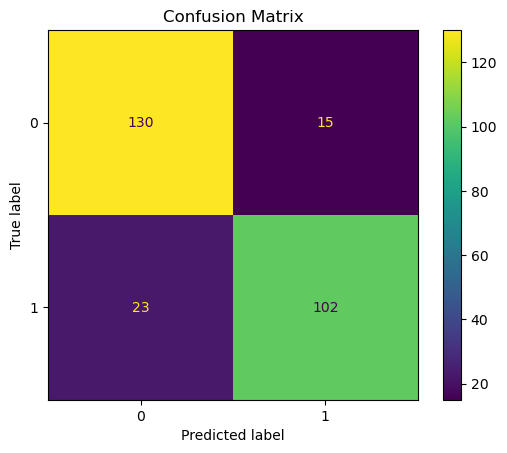

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")

Conclusion

In this project, Logistic Regression was used to predict employee turnover.

The model achieved:

* Accuracy: 85.92%
* Precision: 87.17%
* Recall: 81.6%

From the analysis, it was observed that factors like income, overtime, and years at the company have a strong impact onTurnover.ttrition.

Employees with lower salaries and higher overtime were more likethe companytharameter tuning.
